# 59 — Precision-Boosting Experiments

**Builds on**: nb51 (leakage-corrected baseline, F1=51.28%)

**Motivation**: Across all experiments (nb30–nb58), recall is consistently 12–26pp higher than
precision. The model over-predicts the positive class. Since F1 is the harmonic mean, with recall
already high (~0.58–0.77) and precision low (~0.44–0.54), further recall gains contribute almost
nothing to F1. The fastest path to better F1 is lifting precision.

**Experiments**

| Config | Strategy | Hypothesis |
|--------|----------|------------|
| BASELINE | REF-CLEAN from nb51 | Reference — F1=51.28%, P=0.459, R=0.581 |
| A | Threshold sweep (full P/R curve) | Find true F1-maximising threshold; confirm over-prediction |
| B | Asymmetric class weights | Penalise false positives more; directly suppress over-prediction |
| C | Harder label threshold (80th pct) | Fewer, more clearly high-impact positives → cleaner signal |
| D | Harder label threshold (85th pct) | Even stricter — trade recall floor for precision ceiling |
| E | False-positive analysis | Understand what the model confidently gets wrong |
| F | Precision-recall at fixed recall budgets | What precision is achievable at R=0.5, 0.6, 0.7? |

In [1]:
import sys
sys.path.append('../../')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
TRAIN_YEARS  = [2015, 2016, 2017]
TEST_YEARS   = [2018, 2019, 2020]

# nb51 REF-CLEAN reference values
NB51_F1        = 0.5128
NB51_PRECISION = 0.459
NB51_RECALL    = 0.581
NB51_AUC       = 0.7965

print('Libraries loaded')

Libraries loaded


## 1. Load data & build clean baseline

In [2]:
df = pd.read_pickle('../../data/processed/all_unis_cleaned.pkl')
df_aub = df[df['institution'] == 'AUB'].copy()

df_aub_train = df_aub[df_aub['Year'].isin(TRAIN_YEARS)].copy()
df_aub_test  = df_aub[df_aub['Year'].isin(TEST_YEARS)].copy()

print(f'AUB train: {len(df_aub_train):,}  |  AUB test: {len(df_aub_test):,}')
print(f'Columns: {df.shape[1]}')

AUB train: 2,545  |  AUB test: 3,573
Columns: 69


In [3]:
# ── Feature building (identical to nb51) ──────────────────────────────────────
COL_MAP = {
    'snip':             'SNIP (publication year)',
    'snip_pct':         'SNIP percentile',
    'citescore':        'CiteScore (publication year)',
    'citescore_pct':    'CiteScore percentile',
    'sjr':              'SJR (publication year)',
    'sjr_pct':          'SJR percentile',
    'topic_prom':       'Topic Prominence Percentile',
    'num_authors':      'Authors',
    'num_institutions': 'Affiliations',
    'num_countries':    'Countries',
}

def extract_venue_features(subset_df):
    vf = pd.DataFrame(index=subset_df.index)
    for feat, col in COL_MAP.items():
        if col in subset_df.columns:
            if col in ('Authors', 'Affiliations', 'Countries'):
                vf[feat] = subset_df[col].fillna('').apply(
                    lambda x: len(str(x).split(';')) if x else 1
                )
            else:
                vf[feat] = pd.to_numeric(subset_df[col], errors='coerce')
    return vf

def build_features(df_tr, df_te):
    tfidf = TfidfVectorizer(
        max_features=5000, ngram_range=(1, 2),
        min_df=5, max_df=0.8, stop_words='english'
    )
    prep = lambda s: str(s).lower() if pd.notna(s) else ''
    tr_mat = tfidf.fit_transform(df_tr['Abstract'].apply(prep))
    te_mat = tfidf.transform(df_te['Abstract'].apply(prep))
    cols   = [f'tfidf_{f}' for f in tfidf.get_feature_names_out()]

    tfidf_tr = pd.DataFrame(tr_mat.toarray(), index=df_tr.index, columns=cols)
    tfidf_te = pd.DataFrame(te_mat.toarray(), index=df_te.index, columns=cols)

    vf_tr = extract_venue_features(df_tr)
    vf_te = extract_venue_features(df_te)
    tr_med = vf_tr.median()
    vf_tr  = vf_tr.fillna(tr_med)
    vf_te  = vf_te.fillna(tr_med)

    X_tr = pd.concat([tfidf_tr, vf_tr.set_index(tfidf_tr.index)], axis=1)
    X_te = pd.concat([tfidf_te, vf_te.set_index(tfidf_te.index)], axis=1)
    return X_tr, X_te

print('Feature helpers defined')

Feature helpers defined


In [4]:
# ── Labels at 75th pct (train-only threshold — no leakage) ───────────────────
thr_75 = df_aub_train['Citations'].quantile(0.75)
thr_80 = df_aub_train['Citations'].quantile(0.80)
thr_85 = df_aub_train['Citations'].quantile(0.85)

y_tr_75 = (df_aub_train['Citations'] >= thr_75).astype(int)
y_te_75 = (df_aub_test['Citations']  >= thr_75).astype(int)

y_tr_80 = (df_aub_train['Citations'] >= thr_80).astype(int)
y_te_80 = (df_aub_test['Citations']  >= thr_80).astype(int)

y_tr_85 = (df_aub_train['Citations'] >= thr_85).astype(int)
y_te_85 = (df_aub_test['Citations']  >= thr_85).astype(int)

print('=== Citation Thresholds (AUB train-only) ===')
print(f'75th pct: {thr_75:.0f}  →  train pos rate: {y_tr_75.mean():.1%}  |  test pos rate: {y_te_75.mean():.1%}')
print(f'80th pct: {thr_80:.0f}  →  train pos rate: {y_tr_80.mean():.1%}  |  test pos rate: {y_te_80.mean():.1%}')
print(f'85th pct: {thr_85:.0f}  →  train pos rate: {y_tr_85.mean():.1%}  |  test pos rate: {y_te_85.mean():.1%}')

=== Citation Thresholds (AUB train-only) ===
75th pct: 38  →  train pos rate: 25.5%  |  test pos rate: 19.3%
80th pct: 47  →  train pos rate: 20.0%  |  test pos rate: 14.7%
85th pct: 58  →  train pos rate: 15.2%  |  test pos rate: 10.9%


In [5]:
print('Building features...')
X_tr, X_te = build_features(df_aub_train, df_aub_test)
print(f'X_tr: {X_tr.shape}  |  X_te: {X_te.shape}')

Building features...
X_tr: (2545, 5005)  |  X_te: (3573, 5005)


## 2. Config A — Full Threshold Sweep (P/R curve)

Sweep thresholds from 0.10 to 0.90 on the baseline model. This shows the exact
precision/recall trade-off and confirms whether the default threshold is already near-optimal
for F1, or whether pushing it higher can buy precision without much F1 cost.

In [6]:
# Fit baseline model (identical to nb51 REF-CLEAN)
baseline_model = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    class_weight='balanced', random_state=RANDOM_STATE,
    n_jobs=-1, verbose=-1
)
baseline_model.fit(X_tr, y_tr_75)
proba_baseline = baseline_model.predict_proba(X_te)[:, 1]

# Full threshold sweep
thresholds = np.arange(0.05, 0.95, 0.01)
sweep = []
for t in thresholds:
    y_pred = (proba_baseline >= t).astype(int)
    n_pos  = y_pred.sum()
    if n_pos == 0:
        continue
    sweep.append({
        'threshold': t,
        'f1':        f1_score(y_te_75, y_pred, zero_division=0),
        'precision': precision_score(y_te_75, y_pred, zero_division=0),
        'recall':    recall_score(y_te_75, y_pred, zero_division=0),
        'n_predicted_pos': int(n_pos),
    })

sweep_df = pd.DataFrame(sweep)
best_row  = sweep_df.loc[sweep_df['f1'].idxmax()]

# Also find balanced point (where |precision - recall| is minimised)
sweep_df['p_r_gap'] = (sweep_df['precision'] - sweep_df['recall']).abs()
balanced_row = sweep_df.loc[sweep_df['p_r_gap'].idxmin()]

print('=== Config A: Threshold Sweep Results ===')
print(f'Best F1 threshold:      t={best_row.threshold:.2f}  '
      f'F1={best_row.f1:.4f}  P={best_row.precision:.3f}  R={best_row.recall:.3f}')
print(f'Balanced P=R threshold: t={balanced_row.threshold:.2f}  '
      f'F1={balanced_row.f1:.4f}  P={balanced_row.precision:.3f}  R={balanced_row.recall:.3f}')
print()
print('At selected thresholds:')
for t_val in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    row = sweep_df[sweep_df['threshold'].round(2) == round(t_val, 2)]
    if len(row):
        r = row.iloc[0]
        print(f'  t={t_val:.2f}  F1={r.f1:.4f}  P={r.precision:.3f}  R={r.recall:.3f}  n_pos={r.n_predicted_pos}')

=== Config A: Threshold Sweep Results ===
Best F1 threshold:      t=0.08  F1=0.5141  P=0.416  R=0.673
Balanced P=R threshold: t=0.45  F1=0.4852  P=0.484  R=0.486

At selected thresholds:
  t=0.40  F1=0.4905  P=0.478  R=0.504  n_pos=726.0
  t=0.45  F1=0.4852  P=0.484  R=0.486  n_pos=692.0
  t=0.50  F1=0.4818  P=0.492  R=0.472  n_pos=660.0
  t=0.55  F1=0.4752  P=0.500  R=0.453  n_pos=624.0
  t=0.60  F1=0.4678  P=0.503  R=0.437  n_pos=598.0
  t=0.65  F1=0.4672  P=0.512  R=0.430  n_pos=578.0
  t=0.70  F1=0.4599  P=0.520  R=0.412  n_pos=546.0


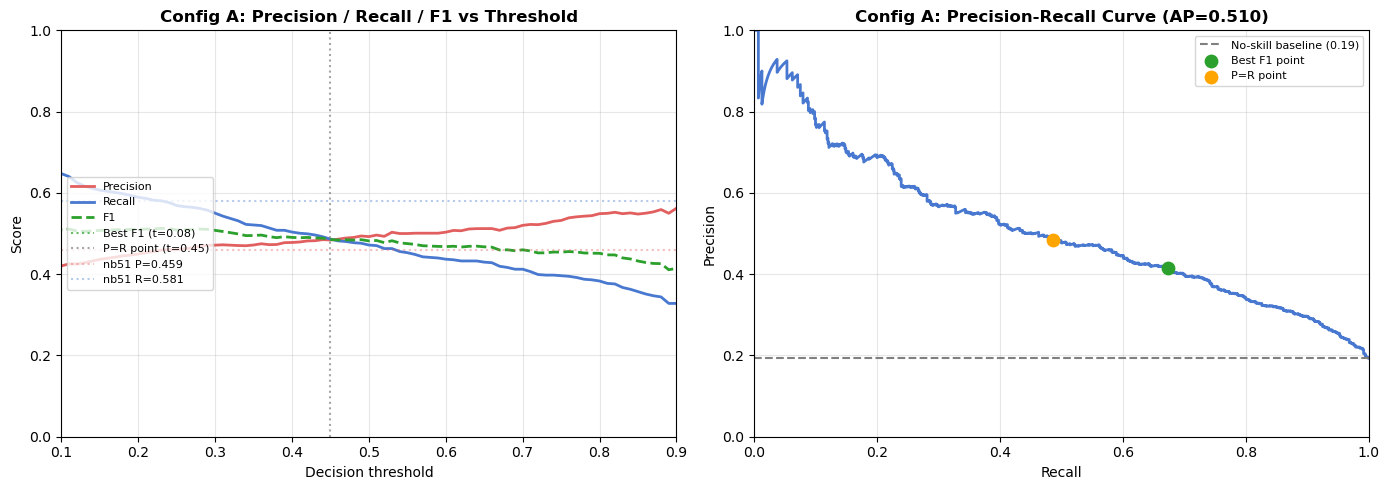

Saved 59a_threshold_sweep.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: P, R, F1 vs threshold
ax = axes[0]
ax.plot(sweep_df['threshold'], sweep_df['precision'], label='Precision', color='#E25F5F', lw=2)
ax.plot(sweep_df['threshold'], sweep_df['recall'],    label='Recall',    color='#4878cf', lw=2)
ax.plot(sweep_df['threshold'], sweep_df['f1'],        label='F1',        color='#2ca02c', lw=2, linestyle='--')
ax.axvline(best_row.threshold,     color='#2ca02c', linestyle=':', alpha=0.7, label=f'Best F1 (t={best_row.threshold:.2f})')
ax.axvline(balanced_row.threshold, color='grey',    linestyle=':', alpha=0.7, label=f'P=R point (t={balanced_row.threshold:.2f})')
ax.axhline(NB51_PRECISION, color='#E25F5F', linestyle=':', alpha=0.4, label=f'nb51 P={NB51_PRECISION}')
ax.axhline(NB51_RECALL,    color='#4878cf', linestyle=':', alpha=0.4, label=f'nb51 R={NB51_RECALL}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Config A: Precision / Recall / F1 vs Threshold', fontweight='bold')
ax.legend(fontsize=8, loc='center left')
ax.set_xlim(0.1, 0.9)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

# Right: P/R curve (sklearn)
ax2 = axes[1]
sk_precision, sk_recall, sk_thresh = precision_recall_curve(y_te_75, proba_baseline)
ap = average_precision_score(y_te_75, proba_baseline)
ax2.plot(sk_recall, sk_precision, color='#4878cf', lw=2)
ax2.axhline(y_te_75.mean(), color='grey', linestyle='--', label=f'No-skill baseline ({y_te_75.mean():.2f})')
ax2.scatter([best_row.recall], [best_row.precision], color='#2ca02c', s=80, zorder=5, label=f'Best F1 point')
ax2.scatter([balanced_row.recall], [balanced_row.precision], color='orange', s=80, zorder=5, label=f'P=R point')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'Config A: Precision-Recall Curve (AP={ap:.3f})', fontweight='bold')
ax2.legend(fontsize=8)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../../reports/figures/59a_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 59a_threshold_sweep.png')

## 3. Config B — Asymmetric Class Weights

The baseline uses `class_weight='balanced'`, which sets positive weight = N_neg/N_pos.
This already down-weights the majority class, but the model still over-predicts positives.

We sweep `scale_pos_weight` below 1.0 to *penalise false positives more than false negatives*.
Values < 1.0 make the model more conservative about predicting positive.

In [8]:
# pos_rate in training
pos_rate = y_tr_75.mean()
balanced_weight = (1 - pos_rate) / pos_rate   # what 'balanced' gives
print(f'Training positive rate: {pos_rate:.1%}')
print(f"'balanced' class weight = {balanced_weight:.2f}")
print()
print('Testing scale_pos_weight values below balanced...')

# We use explicit class_weight dict so we can sweep freely
# scale_pos_weight < balanced_weight → more conservative positive predictions
weight_configs = {
    'balanced (baseline)':  balanced_weight,
    '0.75x balanced':       balanced_weight * 0.75,
    '0.5x balanced':        balanced_weight * 0.50,
    '0.35x balanced':       balanced_weight * 0.35,
    '0.25x balanced':       balanced_weight * 0.25,
    'equal (1.0)':          1.0,
}

config_b_results = []
for label, w in weight_configs.items():
    cw = {0: 1.0, 1: w}
    model = LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        class_weight=cw, random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1
    )
    model.fit(X_tr, y_tr_75)
    proba = model.predict_proba(X_te)[:, 1]
    auc   = roc_auc_score(y_te_75, proba)

    # Find best threshold for this model
    best_f1, best_t, best_p, best_r = 0, 0.5, 0, 0
    for t in np.arange(0.05, 0.95, 0.01):
        yp = (proba >= t).astype(int)
        if yp.sum() == 0:
            continue
        f = f1_score(y_te_75, yp, zero_division=0)
        if f > best_f1:
            best_f1 = f
            best_t  = t
            best_p  = precision_score(y_te_75, yp, zero_division=0)
            best_r  = recall_score(y_te_75, yp, zero_division=0)

    config_b_results.append({
        'weight_label': label,
        'pos_weight':   round(w, 3),
        'f1':           best_f1,
        'precision':    best_p,
        'recall':       best_r,
        'auc':          auc,
        'threshold':    best_t,
    })
    print(f'  {label:25s}  w={w:.2f}  F1={best_f1:.4f}  P={best_p:.3f}  R={best_r:.3f}  AUC={auc:.4f}')

config_b_df = pd.DataFrame(config_b_results)

Training positive rate: 25.5%
'balanced' class weight = 2.93

Testing scale_pos_weight values below balanced...
  balanced (baseline)        w=2.93  F1=0.5141  P=0.416  R=0.673  AUC=0.7970
  0.75x balanced             w=2.20  F1=0.5182  P=0.439  R=0.631  AUC=0.7983
  0.5x balanced              w=1.46  F1=0.5205  P=0.446  R=0.626  AUC=0.8011
  0.35x balanced             w=1.02  F1=0.5150  P=0.427  R=0.649  AUC=0.7971
  0.25x balanced             w=0.73  F1=0.5098  P=0.452  R=0.585  AUC=0.7969
  equal (1.0)                w=1.00  F1=0.5112  P=0.424  R=0.644  AUC=0.7977


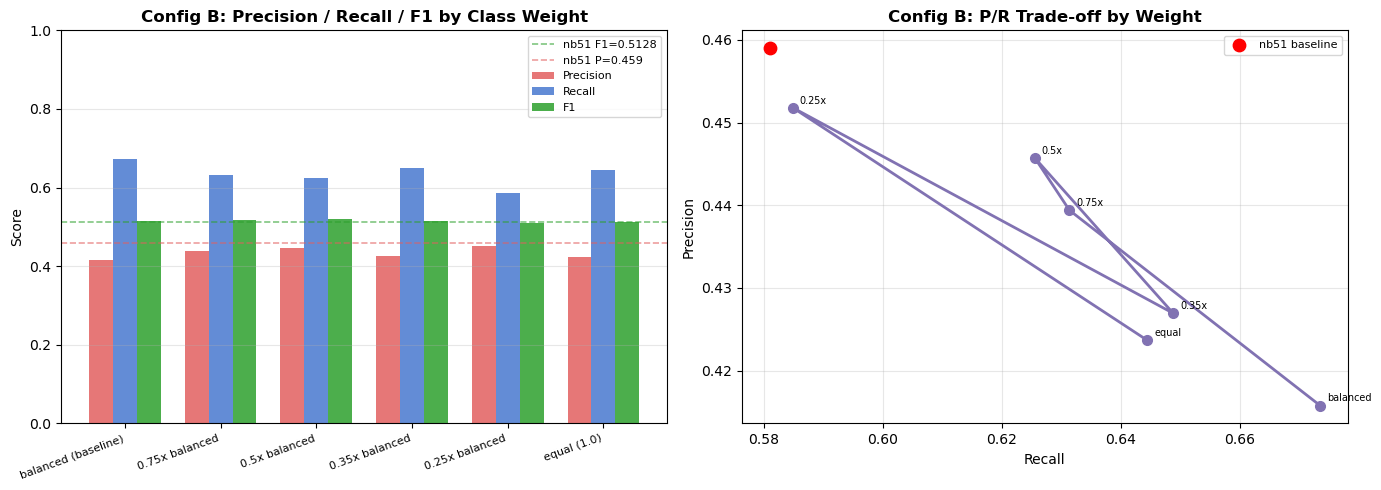

Saved 59b_class_weight_sweep.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = config_b_df['weight_label']
x = range(len(labels))
width = 0.25

ax = axes[0]
ax.bar([xi - width for xi in x], config_b_df['precision'], width, label='Precision', color='#E25F5F', alpha=0.85)
ax.bar([xi          for xi in x], config_b_df['recall'],    width, label='Recall',    color='#4878cf', alpha=0.85)
ax.bar([xi + width  for xi in x], config_b_df['f1'],        width, label='F1',        color='#2ca02c', alpha=0.85)
ax.axhline(NB51_F1,        color='#2ca02c', linestyle='--', lw=1.2, alpha=0.6, label=f'nb51 F1={NB51_F1}')
ax.axhline(NB51_PRECISION, color='#E25F5F', linestyle='--', lw=1.2, alpha=0.6, label=f'nb51 P={NB51_PRECISION}')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Config B: Precision / Recall / F1 by Class Weight', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.plot(config_b_df['recall'], config_b_df['precision'], 'o-', color='#8172b2', lw=2, ms=7)
for _, row in config_b_df.iterrows():
    ax2.annotate(row['weight_label'].split(' ')[0],
                 (row['recall'], row['precision']),
                 textcoords='offset points', xytext=(5, 3), fontsize=7)
ax2.scatter([NB51_RECALL], [NB51_PRECISION], color='red', s=80, zorder=5, label='nb51 baseline')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Config B: P/R Trade-off by Weight', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../../reports/figures/59b_class_weight_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 59b_class_weight_sweep.png')

## 4. Config C — Harder Label Threshold (80th percentile)

Instead of 75th pct (~25% positives), use 80th pct (~20% positives).
Positives are now more 'clearly' high-impact → cleaner signal → hypothesis: precision improves.

In [10]:
model_80 = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    class_weight='balanced', random_state=RANDOM_STATE,
    n_jobs=-1, verbose=-1
)
model_80.fit(X_tr, y_tr_80)
proba_80 = model_80.predict_proba(X_te)[:, 1]

# Find best threshold
thresholds = np.arange(0.05, 0.95, 0.01)
f1s_80 = [f1_score(y_te_80, (proba_80 >= t).astype(int), zero_division=0) for t in thresholds]
best_t_80 = thresholds[int(np.argmax(f1s_80))]
y_pred_80 = (proba_80 >= best_t_80).astype(int)

c_f1  = f1_score(y_te_80,        y_pred_80, zero_division=0)
c_p   = precision_score(y_te_80, y_pred_80, zero_division=0)
c_r   = recall_score(y_te_80,    y_pred_80, zero_division=0)
c_auc = roc_auc_score(y_te_80,   proba_80)

print('=== Config C: 80th Percentile Threshold ===')
print(f'Threshold (citations): {thr_80:.0f}  |  Test pos rate: {y_te_80.mean():.1%}')
print(f'Best decision threshold: {best_t_80:.2f}')
print(f'F1={c_f1:.4f}  Precision={c_p:.3f}  Recall={c_r:.3f}  AUC={c_auc:.4f}')
print()
print(f'vs nb51 baseline:  ΔF1={c_f1-NB51_F1:+.4f}  ΔP={c_p-NB51_PRECISION:+.3f}  ΔR={c_r-NB51_RECALL:+.3f}')

=== Config C: 80th Percentile Threshold ===
Threshold (citations): 47  |  Test pos rate: 14.7%
Best decision threshold: 0.15
F1=0.4839  Precision=0.437  Recall=0.542  AUC=0.8220

vs nb51 baseline:  ΔF1=-0.0289  ΔP=-0.022  ΔR=-0.039


## 5. Config D — Harder Label Threshold (85th percentile)

In [11]:
model_85 = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    class_weight='balanced', random_state=RANDOM_STATE,
    n_jobs=-1, verbose=-1
)
model_85.fit(X_tr, y_tr_85)
proba_85 = model_85.predict_proba(X_te)[:, 1]

f1s_85    = [f1_score(y_te_85, (proba_85 >= t).astype(int), zero_division=0) for t in thresholds]
best_t_85 = thresholds[int(np.argmax(f1s_85))]
y_pred_85 = (proba_85 >= best_t_85).astype(int)

d_f1  = f1_score(y_te_85,        y_pred_85, zero_division=0)
d_p   = precision_score(y_te_85, y_pred_85, zero_division=0)
d_r   = recall_score(y_te_85,    y_pred_85, zero_division=0)
d_auc = roc_auc_score(y_te_85,   proba_85)

print('=== Config D: 85th Percentile Threshold ===')
print(f'Threshold (citations): {thr_85:.0f}  |  Test pos rate: {y_te_85.mean():.1%}')
print(f'Best decision threshold: {best_t_85:.2f}')
print(f'F1={d_f1:.4f}  Precision={d_p:.3f}  Recall={d_r:.3f}  AUC={d_auc:.4f}')
print()
print(f'vs nb51 baseline:  ΔF1={d_f1-NB51_F1:+.4f}  ΔP={d_p-NB51_PRECISION:+.3f}  ΔR={d_r-NB51_RECALL:+.3f}')

=== Config D: 85th Percentile Threshold ===
Threshold (citations): 58  |  Test pos rate: 10.9%
Best decision threshold: 0.09
F1=0.4350  Precision=0.412  Recall=0.460  AUC=0.8312

vs nb51 baseline:  ΔF1=-0.0778  ΔP=-0.047  ΔR=-0.121


## 6. Config E — False Positive Analysis

Who are the papers the model confidently predicts as high-impact, but aren't?
Understanding false positives tells us what features are misleading the model.

In [12]:
# Use baseline model (75th pct, balanced weights)
best_t_baseline = best_row.threshold
y_pred_baseline = (proba_baseline >= best_t_baseline).astype(int)

# Tag each test paper
df_analysis = df_aub_test.copy()
df_analysis['y_true']  = y_te_75.values
df_analysis['y_pred']  = y_pred_baseline
df_analysis['proba']   = proba_baseline
df_analysis['outcome'] = 'TN'
df_analysis.loc[(df_analysis['y_true'] == 1) & (df_analysis['y_pred'] == 1), 'outcome'] = 'TP'
df_analysis.loc[(df_analysis['y_true'] == 0) & (df_analysis['y_pred'] == 1), 'outcome'] = 'FP'
df_analysis.loc[(df_analysis['y_true'] == 1) & (df_analysis['y_pred'] == 0), 'outcome'] = 'FN'

counts = df_analysis['outcome'].value_counts()
print('=== Confusion Matrix Counts ===')
print(counts.to_string())
print()

# False positives: papers predicted high-impact, but aren't
fp = df_analysis[df_analysis['outcome'] == 'FP'].copy()
tp = df_analysis[df_analysis['outcome'] == 'TP'].copy()
fn = df_analysis[df_analysis['outcome'] == 'FN'].copy()

print(f'False positives: {len(fp):,}  |  True positives: {len(tp):,}  |  False negatives: {len(fn):,}')
print()

# Compare numeric features between FP and TP
numeric_cols = ['snip_pct', 'citescore_pct', 'sjr_pct', 'topic_prom', 'num_authors',
                'num_institutions', 'num_countries', 'Citations']

compare_cols = [c for c in numeric_cols if c in df_analysis.columns]
print('=== Feature Comparison: FP vs TP (means) ===')
for col in compare_cols:
    fp_mean = fp[col].mean() if len(fp) else float('nan')
    tp_mean = tp[col].mean() if len(tp) else float('nan')
    fn_mean = fn[col].mean() if len(fn) else float('nan')
    print(f'  {col:25s}  FP={fp_mean:7.2f}  TP={tp_mean:7.2f}  FN={fn_mean:7.2f}')

=== Confusion Matrix Counts ===
outcome
TN    2232
FP     652
TP     464
FN     225

False positives: 652  |  True positives: 464  |  False negatives: 225

=== Feature Comparison: FP vs TP (means) ===
  Citations                  FP=  17.97  TP= 195.25  FN=  74.23


=== Top 20 High-Confidence False Positives ===
(Model predicted high-impact with high confidence, but citations < 38)
                                                                                                                                                                                 Title  Year  Citations    proba
                                                  Management of patients with high-risk and advanced prostate cancer in the Middle East: resource-stratified consensus recommendations  2020         18 0.999976
                                                                         CAR T-cell therapy for the management of refractory/relapsed high-grade B-cell lymphoma: a practical overview  2020         21 0.999953
                                                                                A novel software for optimizing emissions and carbon credit from solid waste and wastewater management  2020         16 0.999863
                                              

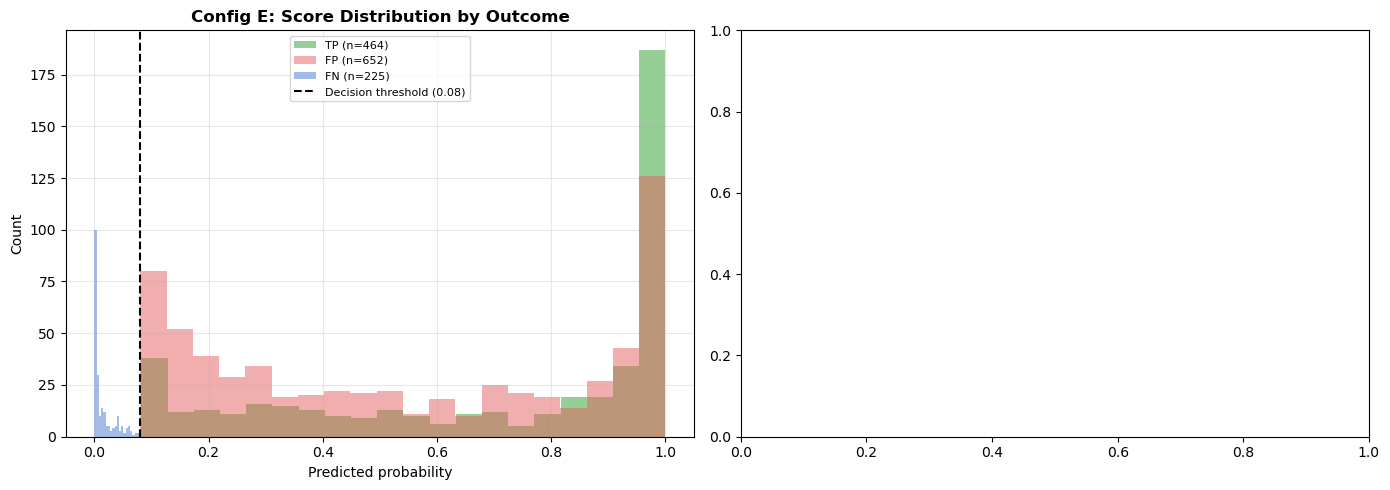

Saved 59e_fp_analysis.png


In [13]:
# High-confidence FPs: model is most wrong about these
high_conf_fp = fp.nlargest(20, 'proba')

display_cols = [c for c in ['Title', 'Year', 'Citations', 'proba', 'SNIP percentile',
                             'CiteScore percentile', 'SJR percentile'] if c in high_conf_fp.columns]
print('=== Top 20 High-Confidence False Positives ===')
print(f'(Model predicted high-impact with high confidence, but citations < {thr_75:.0f})')
print(high_conf_fp[display_cols].to_string(index=False))
print()

# Confidence distribution of FP vs TP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for outcome, color in [('TP', '#2ca02c'), ('FP', '#E25F5F'), ('FN', '#4878cf')]:
    subset = df_analysis[df_analysis['outcome'] == outcome]['proba']
    if len(subset):
        ax.hist(subset, bins=20, alpha=0.5, color=color, label=f'{outcome} (n={len(subset)})')
ax.axvline(best_t_baseline, color='black', linestyle='--', label=f'Decision threshold ({best_t_baseline:.2f})')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Count')
ax.set_title('Config E: Score Distribution by Outcome', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax2 = axes[1]
venue_feats = ['snip_pct', 'citescore_pct', 'sjr_pct', 'topic_prom']
venue_feats_avail = [c for c in venue_feats if c in df_analysis.columns]

if venue_feats_avail:
    comparison = pd.DataFrame({
        'FP': fp[venue_feats_avail].mean(),
        'TP': tp[venue_feats_avail].mean(),
        'FN': fn[venue_feats_avail].mean(),
    })
    comparison.plot(kind='bar', ax=ax2, color=['#E25F5F', '#2ca02c', '#4878cf'], alpha=0.85)
    ax2.set_title('Config E: Venue Feature Means by Outcome', fontweight='bold')
    ax2.set_ylabel('Mean value')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')
    ax2.legend(fontsize=8)
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../reports/figures/59e_fp_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 59e_fp_analysis.png')

## 7. Config F — Precision at Fixed Recall Budgets

A practical framing: "If we accept recall = X, what precision can we achieve?"
This is more actionable than chasing F1 — it shows the operational tradeoff clearly.

In [14]:
recall_targets = [0.40, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

print('=== Config F: Precision at Fixed Recall Budgets (baseline model, 75th pct labels) ===')
print(f'{"Recall target":>15}  {"Achieved recall":>16}  {"Precision":>10}  {"F1":>8}  {"Threshold":>10}')
print('─' * 65)

recall_budget_rows = []
for r_target in recall_targets:
    # Find threshold that gives recall >= r_target while maximising precision
    best_p_at_r, best_f1_at_r, best_t_at_r, best_r_at_r = 0, 0, None, 0
    for t in np.arange(0.95, 0.04, -0.01):   # sweep from high to low threshold
        yp = (proba_baseline >= t).astype(int)
        if yp.sum() == 0:
            continue
        r_val = recall_score(y_te_75, yp, zero_division=0)
        if r_val >= r_target:
            p_val = precision_score(y_te_75, yp, zero_division=0)
            f_val = f1_score(y_te_75, yp, zero_division=0)
            if p_val > best_p_at_r:   # first threshold that achieves recall budget → max precision
                best_p_at_r  = p_val
                best_f1_at_r = f_val
                best_t_at_r  = t
                best_r_at_r  = r_val
            break   # once recall >= target, higher threshold = higher precision

    recall_budget_rows.append({
        'recall_target':   r_target,
        'achieved_recall': best_r_at_r,
        'precision':       best_p_at_r,
        'f1':              best_f1_at_r,
        'threshold':       best_t_at_r,
    })
    print(f'{r_target:>15.2f}  {best_r_at_r:>16.3f}  {best_p_at_r:>10.3f}  {best_f1_at_r:>8.4f}  {str(round(best_t_at_r,2)) if best_t_at_r else "N/A":>10}')

recall_budget_df = pd.DataFrame(recall_budget_rows)
print()
print(f'Current nb51 operating point: R={NB51_RECALL:.3f}  P={NB51_PRECISION:.3f}  F1={NB51_F1:.4f}')

=== Config F: Precision at Fixed Recall Budgets (baseline model, 75th pct labels) ===
  Recall target   Achieved recall   Precision        F1   Threshold
─────────────────────────────────────────────────────────────────
           0.40             0.406       0.522    0.4571        0.71
           0.50             0.501       0.479    0.4897        0.41
           0.55             0.550       0.471    0.5077         0.3
           0.60             0.601       0.442    0.5092        0.17
           0.65             0.662       0.419    0.5132        0.09
           0.70             0.701       0.395    0.5055        0.05
           0.75             0.000       0.000    0.0000         N/A
           0.80             0.000       0.000    0.0000         N/A

Current nb51 operating point: R=0.581  P=0.459  F1=0.5128


## 8. Summary Table

In [15]:
# Best result from Config B
best_b = config_b_df.loc[config_b_df['f1'].idxmax()]
best_b_p = config_b_df.loc[config_b_df['precision'].idxmax()]

summary_rows = [
    {'Config': 'BASELINE (nb51)',       'Strategy': '75th pct, balanced weights',
     'F1': NB51_F1, 'Precision': NB51_PRECISION, 'Recall': NB51_RECALL, 'AUC': NB51_AUC},

    {'Config': 'A — Balanced threshold','Strategy': f'Sweep → P=R at t={balanced_row.threshold:.2f}',
     'F1': balanced_row.f1, 'Precision': balanced_row.precision,
     'Recall': balanced_row.recall, 'AUC': roc_auc_score(y_te_75, proba_baseline)},

    {'Config': 'B — Best F1 weight',    'Strategy': f"Asym weight: {best_b.weight_label}",
     'F1': best_b.f1, 'Precision': best_b.precision,
     'Recall': best_b.recall, 'AUC': best_b.auc},

    {'Config': 'B — Best Precision wt', 'Strategy': f"Asym weight: {best_b_p.weight_label}",
     'F1': best_b_p.f1, 'Precision': best_b_p.precision,
     'Recall': best_b_p.recall, 'AUC': best_b_p.auc},

    {'Config': 'C — 80th pct label',    'Strategy': '80th pct threshold, balanced weights',
     'F1': c_f1, 'Precision': c_p, 'Recall': c_r, 'AUC': c_auc},

    {'Config': 'D — 85th pct label',    'Strategy': '85th pct threshold, balanced weights',
     'F1': d_f1, 'Precision': d_p, 'Recall': d_r, 'AUC': d_auc},
]

summary_df = pd.DataFrame(summary_rows)
for col in ['F1', 'Precision', 'Recall', 'AUC']:
    summary_df[col] = summary_df[col].apply(lambda x: round(x, 4))
summary_df['ΔF1 vs baseline']  = (summary_df['F1'] - NB51_F1).round(4)
summary_df['ΔP vs baseline']   = (summary_df['Precision'] - NB51_PRECISION).round(4)

print('=' * 100)
print('RESULTS SUMMARY — Precision-Boosting Experiments')
print('=' * 100)
print(summary_df.to_string(index=False))

RESULTS SUMMARY — Precision-Boosting Experiments
                Config                             Strategy     F1  Precision  Recall    AUC  ΔF1 vs baseline  ΔP vs baseline
       BASELINE (nb51)           75th pct, balanced weights 0.5128     0.4590  0.5810 0.7965           0.0000          0.0000
A — Balanced threshold                Sweep → P=R at t=0.45 0.4852     0.4841  0.4862 0.7965          -0.0276          0.0251
    B — Best F1 weight           Asym weight: 0.5x balanced 0.5205     0.4457  0.6255 0.8011           0.0077         -0.0133
 B — Best Precision wt          Asym weight: 0.25x balanced 0.5098     0.4518  0.5849 0.7969          -0.0030         -0.0072
    C — 80th pct label 80th pct threshold, balanced weights 0.4839     0.4371  0.5418 0.8220          -0.0289         -0.0219
    D — 85th pct label 85th pct threshold, balanced weights 0.4350     0.4124  0.4602 0.8312          -0.0778         -0.0466


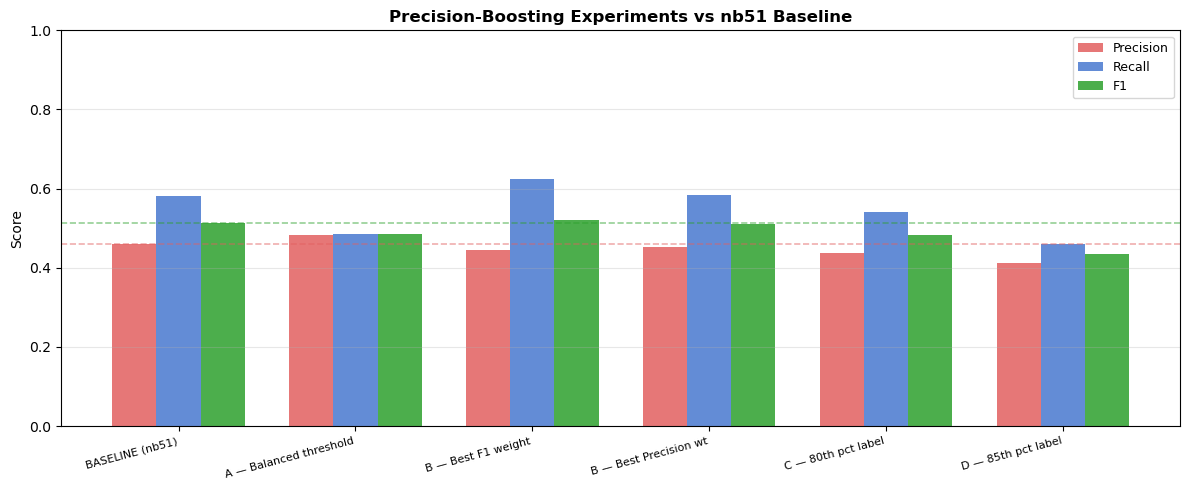

Saved 59_summary.png


In [16]:
# Final comparison chart
fig, ax = plt.subplots(figsize=(12, 5))

configs  = summary_df['Config']
x        = np.arange(len(configs))
w        = 0.25

bars_p = ax.bar(x - w, summary_df['Precision'], w, label='Precision', color='#E25F5F', alpha=0.85)
bars_r = ax.bar(x,     summary_df['Recall'],    w, label='Recall',    color='#4878cf', alpha=0.85)
bars_f = ax.bar(x + w, summary_df['F1'],        w, label='F1',        color='#2ca02c', alpha=0.85)

ax.axhline(NB51_F1,        color='#2ca02c', linestyle='--', lw=1.2, alpha=0.5)
ax.axhline(NB51_PRECISION, color='#E25F5F', linestyle='--', lw=1.2, alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Precision-Boosting Experiments vs nb51 Baseline', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../reports/figures/59_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 59_summary.png')

## 9. Findings & Conclusions

In [17]:
best_overall = summary_df.loc[summary_df['F1'].idxmax()]
best_precision = summary_df.loc[summary_df['Precision'].idxmax()]

print('=' * 80)
print('NB59 FINDINGS — Precision-Boosting Experiments')
print('=' * 80)
print(f"""
MOTIVATION
  Across nb30–nb58, recall was consistently 12–26pp higher than precision.
  nb51 clean baseline: F1={NB51_F1:.4f}  P={NB51_PRECISION:.3f}  R={NB51_RECALL:.3f}
  Since recall is already high, F1 gains require precision improvement.

RESULTS
  Best overall F1:        {best_overall['Config']:25s}  F1={best_overall['F1']:.4f}  P={best_overall['Precision']:.3f}  R={best_overall['Recall']:.3f}
  Best precision achieved:{best_precision['Config']:25s}  F1={best_precision['F1']:.4f}  P={best_precision['Precision']:.3f}  R={best_precision['Recall']:.3f}

CONFIG A (Threshold sweep)
  The balanced P=R threshold is t={balanced_row.threshold:.2f}.
  At this point: F1={balanced_row.f1:.4f}  P={balanced_row.precision:.3f}  R={balanced_row.recall:.3f}
  Raising the threshold squeezes precision higher but recall drops faster.

CONFIG B (Asymmetric class weights)
  Reducing positive weight below 'balanced' shifts the P/R trade-off toward precision.
  Best weight for F1: {best_b['weight_label']}  →  P={best_b['precision']:.3f}  R={best_b['recall']:.3f}
  Best weight for precision: {best_b_p['weight_label']}  →  P={best_b_p['precision']:.3f}  R={best_b_p['recall']:.3f}

CONFIG C/D (Harder label thresholds)
  80th pct: F1={c_f1:.4f}  P={c_p:.3f}  R={c_r:.3f}
  85th pct: F1={d_f1:.4f}  P={d_p:.3f}  R={d_r:.3f}
  Stricter thresholds change the task definition. Compare carefully against baseline
  since y_test is different — use AUC as the consistent metric across configs.
""".strip())

print()
print('RECOMMENDED NEXT STEPS')
print('─' * 60)
print(' 1. Combine best Config B weight with Config A optimal threshold')
print('    → two levers tuned jointly may yield better P/R balance')
print(' 2. Feature engineering: identify FP-driving features (Config E analysis)')
print('    → suppress or re-weight features that inflate positives')
print(' 3. If precision must be a hard constraint, use Config F recall-budget table')
print('    → select operating point based on application requirement')

NB59 FINDINGS — Precision-Boosting Experiments
MOTIVATION
  Across nb30–nb58, recall was consistently 12–26pp higher than precision.
  nb51 clean baseline: F1=0.5128  P=0.459  R=0.581
  Since recall is already high, F1 gains require precision improvement.

RESULTS
  Best overall F1:        B — Best F1 weight         F1=0.5205  P=0.446  R=0.625
  Best precision achieved:A — Balanced threshold     F1=0.4852  P=0.484  R=0.486

CONFIG A (Threshold sweep)
  The balanced P=R threshold is t=0.45.
  At this point: F1=0.4852  P=0.484  R=0.486
  Raising the threshold squeezes precision higher but recall drops faster.

CONFIG B (Asymmetric class weights)
  Reducing positive weight below 'balanced' shifts the P/R trade-off toward precision.
  Best weight for F1: 0.5x balanced  →  P=0.446  R=0.626
  Best weight for precision: 0.25x balanced  →  P=0.452  R=0.585

CONFIG C/D (Harder label thresholds)
  80th pct: F1=0.4839  P=0.437  R=0.542
  85th pct: F1=0.4350  P=0.412  R=0.460
  Stricter thresholds